# SIFT-Based Image Retrieval

In this exercise, you will build a simple image search engine using the SIFT feature detector and descriptor. You will work with a folder containing several images. **One image will be randomly selected as the query**, and your goal is to:


1.   **Extract SIFT descriptors** from all images in the folder.
2.   Use descriptors to **measure similarity** between the query image and every other image.
3.   **Rank the images** by similarity.
4.   **Visualize top-3** most similar images.
5.   For every image visualized, **show first 10 SIFT keypoints**.

Style of the result should be similar to this example:

<img src="P4_E1.png"/>

RECOMMENDATIONS:
- Do it step by step, first top-1 and then extend it for top-3.
- Do not leave the exercise blank, do as much as you know and present it properly.
- Use whatever distance suits you better but **specify it**.


In [8]:
import glob
import os
from skimage.feature import match_descriptors, plot_matches, SIFT
import numpy as np
from skimage import io, color, transform, feature, measure
import matplotlib.pyplot as plt




def ensure_gray(image):
    if image.ndim == 3:
        if image.shape[-1] == 4:
            image = color.rgba2rgb(image)
        if image.shape[-1] == 3:
            return color.rgb2gray(image)
    return image

def normalize(image):
    if image.max() > 1.:
        image = image.astype(np.float32) / 255.
    return image

In [29]:

def get_SIFT(image, n_octaves=4, n_scales=3, sigma=1.6):

    # Asegurar que esté en escala de grises
    image = ensure_gray(image)
    # Normalizar al rango [0,1] (SIFT espera una entrada de tipo float)
    image = normalize(image)

    # Crear el objeto SIFT con los parámetros de espacio-escala solicitados
    sift = SIFT(n_octaves=n_octaves, n_scales=n_scales, sigma_min=sigma)
    # Detectar puntos clave (keypoints) y calcular descriptores
    sift.detect_and_extract(image)
    # Los keypoints son (fila, columna), los descriptores son arrays de floats
    return sift.keypoints, sift.descriptors

In [35]:

def match_sift_images(model_path, scene_path,
                      n_octaves=4, n_scales=3, sigma=1.6,
                      max_ratio=0.8, cross_check=False,
                      metric='euclidean', plot_top=300):

    # load images (allow passing already-loaded arrays)
    model = io.imread(model_path) if isinstance(model_path, str) else model_path
    scene = io.imread(scene_path) if isinstance(scene_path, str) else scene_path
    
    # Ensure grayscale for SIFT
    model_g = ensure_gray(model)
    scene_g = ensure_gray(scene)

    # detect SIFT keypoints & descriptors
    kp1, desc1 = get_SIFT(model_g, n_octaves=n_octaves, n_scales=n_scales, sigma=sigma)
    kp2, desc2 = get_SIFT(scene_g, n_octaves=n_octaves, n_scales=n_scales, sigma=sigma)

    # matching (uses ratio test internally when max_ratio is set)
    matches = match_descriptors(desc1, desc2,
                                cross_check=cross_check,
                                max_ratio=max_ratio,
                                metric=metric)


    return dict(keypoints_model=kp1, desc_model=desc1,
                keypoints_scene=kp2, desc_scene=desc2,
                matches=matches)


In [84]:
# Continue Here...

def find_top_n_matches(reference_path,
                       folder="images",
                       n_octaves=8, n_scales=3, sigma=1.6,
                       max_ratio=0.8, metric='euclidean',
                       top_n=3): # <--- Nuevo parámetro: Cuántos quieres

    # --- 1. PREPARAR REFERENCIA ---
    ref_im = io.imread(reference_path)
    ref_proc = normalize(ensure_gray(ref_im)) # Tu imagen procesada
    # SIFT Referencia
    sift_ref = SIFT(n_octaves=n_octaves, n_scales=n_scales, sigma_min=sigma)
    sift_ref.detect_and_extract(ref_proc)
    desc_ref = sift_ref.descriptors
    kp_ref = sift_ref.keypoints

    # --- 2. ITERAR Y GUARDAR TODOS LOS CANDIDATOS ---
    paths = sorted(glob.glob(os.path.join(folder, "*")))
    paths = [p for p in paths]
    
    all_candidates = [] # <--- Aquí guardaremos diccionarios

    for p in paths:
        # Cargar y procesar candidato
        im = io.imread(p)
        img_proc = normalize(ensure_gray(im)) # <--- La imagen que querías guardar

        # SIFT Candidato
        sift_i = SIFT(n_octaves=n_octaves, n_scales=n_scales, sigma_min=sigma)
        sift_i.detect_and_extract(img_proc)
        desc_i = sift_i.descriptors
        kp_i = sift_i.keypoints

        # Matching
        if desc_ref is None or desc_i is None or len(desc_ref)==0 or len(desc_i)==0:
            cnt = 0
            matches = np.zeros((0,2), dtype=int)
        else:
            matches = match_descriptors(desc_ref, desc_i, cross_check=True, max_ratio=max_ratio, metric=metric)
            cnt = matches.shape[0]

        # Guardamos un diccionario completo en la lista
        candidate_data = {
            'count': cnt,
            'path': p,
            'image_processed': img_proc, # <--- Guardamos la imagen procesada como pediste
            'keypoints': kp_i,
            'descriptors': desc_i,
            'matches': matches
        }
        all_candidates.append(candidate_data)

    # --- 3. ORDENAR Y SELECCIONAR TOP N ---
    # Ordenamos la lista de diccionarios basándonos en la clave 'count'
    # reverse=True para que sea de mayor a menor
    
    sorted_candidates = sorted(all_candidates, key=lambda x: x['count'], reverse=True)
    
    # Nos quedamos con los N primeros
    top_candidates = sorted_candidates[:top_n]

    if not top_candidates:
        print("No matches found.")
        return None

    # --- 4. VISUALIZAR LOS TOP N ---
    # Creamos subplots dinámicos según el número de top_n
    fig, ax = plt.subplots(1, len(top_candidates)+1, figsize=(15, 5))
    img_cand = top_candidates[0]['image_processed']
    kp_cand = top_candidates[0]['keypoints'][:10]
    ax[0].imshow(img_cand, cmap='gray')
    ax[0].scatter(kp_cand[:, 1], kp_cand[:, 0], 
                  s=30,          # Tamaño del punto
                  c='yellow',       # Color
                  marker='*')    # Forma de estrella (o '.' para punto)
    ax[0].set_title(f"SIFT Query\n {os.path.basename(top_candidates[0]['path'])}")
    ax[0].axis('off')
    # Si top_n es 1, axes no es una lista, lo convertimos para que el loop funcione
    if len(top_candidates) == 1: ax = [ax]
    else:
        
        for i, candidate in enumerate(top_candidates):

            img_cand = candidate['image_processed']
            kp_cand = candidate['keypoints'][:10]
            ax[i+1].imshow(img_cand, cmap='gray')

            # 2. AHORA haz el scatter de los keypoints
            # kp_cand[:, 1] son las X (columnas)
            # kp_cand[:, 0] son las Y (filas)
            ax[i+1].scatter(kp_cand[:, 1], kp_cand[:, 0], 
                          s=30,          # Tamaño del punto
                          c='yellow',       # Color
                          marker='*')    # Forma de estrella (o '.' para punto)
            ax[i+1].set_title(f"SIFT Rank{i+1}\n {os.path.basename(candidate['path'])}")
            ax[i+1].axis('off')

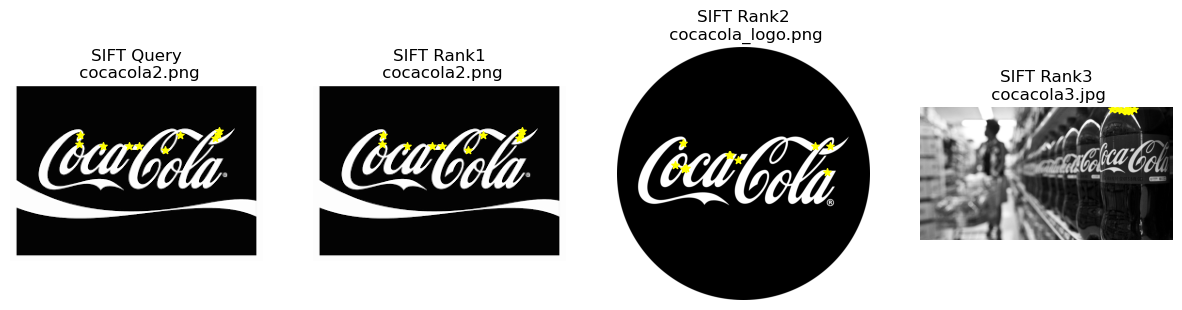

In [85]:
find_top_n_matches("images/cocacola2.png", folder="images", n_octaves=8, n_scales=3, sigma=1.6,
                                                            max_ratio=0.5, metric='euclidean',
                                                            top_n=3)